# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Gael Alejandro Cordova Diaz

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
#Importar las librerias 
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [50]:
#Cargar el dataset
df = pd.read_csv("ventas-por-factura.csv")
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [51]:
print("Tamaño original del dataset:", df.shape)
df.info()

Tamaño original del dataset: (25953, 6)
<class 'pandas.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  str    
 1   Fecha de factura  25953 non-null  str    
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  str    
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.2 MB


In [52]:
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [53]:
df.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [54]:
df.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [55]:
(df.isnull().sum() / len(df)) * 100

N° de factura        0.000000
Fecha de factura     0.000000
ID Cliente          14.349016
País                 0.000000
Cantidad             0.000000
Monto                0.000000
dtype: float64

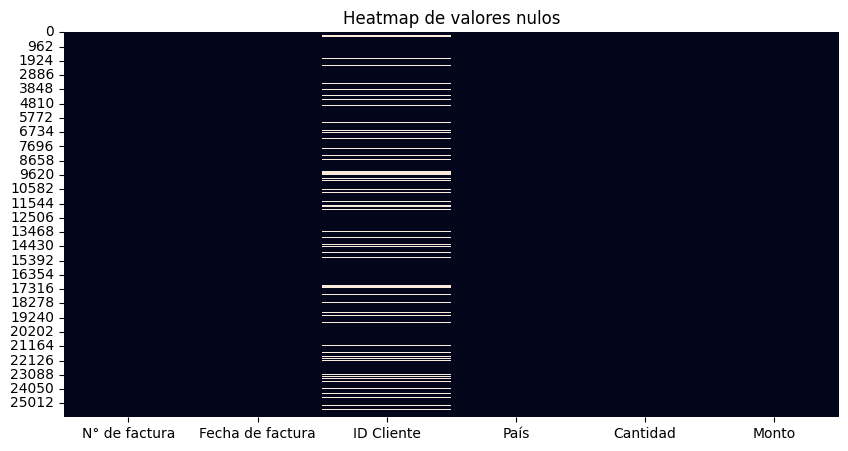

In [56]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Heatmap de valores nulos")
plt.show()

In [57]:
print("Duplicados encontrados:", df.duplicated().sum())
df[df.duplicated()]

Duplicados encontrados: 10


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
7626,568403,9/27/2021 10:35:00,NaN,United Kingdom,-3,"0,00"
9728,C581390,12/8/2021 13:13:00,13081.0,United Kingdom,-13,"-15,85"
11263,568417,9/27/2021 11:10:00,14911.0,EIRE,202,"776,30"
12533,C581384,12/8/2021 13:06:00,17673.0,United Kingdom,-2,"-6,90"
13011,568423,9/27/2021 11:24:00,17061.0,United Kingdom,118,"573,40"
13054,568387,9/27/2021 10:04:00,13704.0,United Kingdom,340,"422,32"
15861,568384,9/27/2021 9:46:00,12748.0,United Kingdom,1,"0,00"
18795,C581323,12/8/2021 11:53:00,14442.0,Channel Islands,-1,"-4,25"
22578,C581330,12/8/2021 11:57:00,15877.0,United Kingdom,-125,"-52,50"
25704,568404,9/27/2021 10:36:00,NaN,United Kingdom,-17,"0,00"


In [58]:
df = df.drop_duplicates()
print("Después de eliminar duplicados:", df.shape)

Después de eliminar duplicados: (25943, 6)


In [61]:
#Identificar facturas canceladas
facturas_canceladas = df[df["N° de factura"].astype(str).str.startswith("C")]

print("Facturas canceladas encontradas:", facturas_canceladas.shape[0])
facturas_canceladas.head()

Facturas canceladas encontradas: 3837


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"


In [62]:
df = df[~df["N° de factura"].astype(str).str.startswith("C")]
print("Después de eliminar facturas canceladas:", df.shape)

Después de eliminar facturas canceladas: (22106, 6)


In [63]:
df["Monto"] = df["Monto"].astype(str).str.replace(",", ".", regex=False)
df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

print("Después de convertir Monto:", df.shape)
df.info()

Después de convertir Monto: (22106, 6)
<class 'pandas.DataFrame'>
Index: 22106 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     22106 non-null  str    
 1   Fecha de factura  22106 non-null  str    
 2   ID Cliente        18566 non-null  float64
 3   País              22106 non-null  str    
 4   Cantidad          22106 non-null  int64  
 5   Monto             22106 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.2 MB


In [64]:
print("Montos inválidos:", df["Monto"].isnull().sum())

Montos inválidos: 0


In [65]:
df = df.dropna(subset=["Monto"])
print("Después de eliminar montos inválidos:", df.shape)

Después de eliminar montos inválidos: (22106, 6)


In [67]:
#Convertit fecha a tipo datetime
df["Fecha de factura"] = pd.to_datetime(
    df["Fecha de factura"],
    errors="coerce"
)

print("Fechas inválidas:", df["Fecha de factura"].isnull().sum())

Fechas inválidas: 0


In [68]:
df = df.dropna(subset=["Fecha de factura"])
print("Después de eliminar fechas inválidas:", df.shape)

Después de eliminar fechas inválidas: (22106, 6)


In [69]:
#Identificar valores negativos dentro del rango
cantidad_invalida = df[df["Cantidad"] <= 0]

print("Registros con cantidad inválida:", cantidad_invalida.shape[0])
cantidad_invalida.head()

Registros con cantidad inválida: 1336


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
16,542418,2021-01-27 17:39:00,NaN,United Kingdom,-17,0.0
21,550759,2021-04-20 12:09:00,NaN,United Kingdom,-7,0.0
123,549142,2021-04-06 15:26:00,NaN,United Kingdom,-24,0.0
126,576674,2021-11-16 12:00:00,NaN,United Kingdom,-6,0.0
175,541967,2021-01-24 13:35:00,NaN,United Kingdom,-3,0.0


In [70]:
monto_invalido = df[df["Monto"] <= 0]

print("Registros con monto inválido:", monto_invalido.shape[0])
monto_invalido.head()

Registros con monto inválido: 2104


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
16,542418,2021-01-27 17:39:00,NaN,United Kingdom,-17,0.0
21,550759,2021-04-20 12:09:00,NaN,United Kingdom,-7,0.0
71,558245,2021-06-27 16:28:00,NaN,United Kingdom,8,0.0
123,549142,2021-04-06 15:26:00,NaN,United Kingdom,-24,0.0
126,576674,2021-11-16 12:00:00,NaN,United Kingdom,-6,0.0


In [71]:
df = df[df["Cantidad"] > 0]
df = df[df["Monto"] > 0]

print("Después de eliminar cantidades y montos inválidos:", df.shape)

Después de eliminar cantidades y montos inválidos: (20002, 6)


In [72]:
df["Cantidad"]

0         123
1         163
3           1
4         357
5          91
         ... 
25945     432
25946      28
25949     488
25950     104
25951    1176
Name: Cantidad, Length: 20002, dtype: int64

In [73]:
#Identificar clientes nulos
print("Clientes nulos:", df["ID Cliente"].isnull().sum())

df[df["ID Cliente"].isnull()].head()

Clientes nulos: 1440


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
11,539736,2020-12-21 15:18:00,NaN,United Kingdom,143,1172.46
12,537823,2020-12-08 14:25:00,NaN,United Kingdom,1484,6073.71
23,556427,2021-06-10 13:23:00,NaN,United Kingdom,92,435.69
28,562417,2021-08-04 16:32:00,NaN,United Kingdom,526,1691.38
41,549684,2021-04-11 13:24:00,NaN,United Kingdom,1,30.00


In [74]:
df = df.dropna(subset=["ID Cliente"])
print("Después de eliminar clientes nulos:", df.shape)

Después de eliminar clientes nulos: (18562, 6)


In [75]:
df["ID Cliente"] = df["ID Cliente"].astype(int)
df.info()

<class 'pandas.DataFrame'>
Index: 18562 entries, 0 to 25951
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     18562 non-null  str           
 1   Fecha de factura  18562 non-null  datetime64[us]
 2   ID Cliente        18562 non-null  int64         
 3   País              18562 non-null  str           
 4   Cantidad          18562 non-null  int64         
 5   Monto             18562 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 1015.1 KB


In [76]:
#Limpiar el formato del país
df["País"].unique()

<StringArray>
[      'United Kingdom',              'Germany',                 'EIRE',
               'France',               'Sweden',              'Belgium',
                'Italy',               'Israel',             'Portugal',
          'Netherlands',      'Channel Islands',          'Switzerland',
              'Finland',                'Spain',                'Japan',
 'United Arab Emirates',            'Singapore',               'Norway',
              'Denmark',            'Australia',                  'USA',
            'Lithuania',   'European Community',              'Austria',
               'Cyprus',              'Iceland',          'Unspecified',
                'Malta',               'Canada',               'Greece',
               'Poland',       'Czech Republic',              'Lebanon',
               'Brazil',                  'RSA',              'Bahrain',
         'Saudi Arabia']
Length: 37, dtype: str

In [77]:
df["País"] = df["País"].astype(str).str.strip().str.title()

df["País"].unique()

<StringArray>
[      'United Kingdom',              'Germany',                 'Eire',
               'France',               'Sweden',              'Belgium',
                'Italy',               'Israel',             'Portugal',
          'Netherlands',      'Channel Islands',          'Switzerland',
              'Finland',                'Spain',                'Japan',
 'United Arab Emirates',            'Singapore',               'Norway',
              'Denmark',            'Australia',                  'Usa',
            'Lithuania',   'European Community',              'Austria',
               'Cyprus',              'Iceland',          'Unspecified',
                'Malta',               'Canada',               'Greece',
               'Poland',       'Czech Republic',              'Lebanon',
               'Brazil',                  'Rsa',              'Bahrain',
         'Saudi Arabia']
Length: 37, dtype: str

In [78]:
#Transformar datos de fecha
df["Año"] = df["Fecha de factura"].dt.year
df["Mes"] = df["Fecha de factura"].dt.month
df["Día"] = df["Fecha de factura"].dt.day
df["Hora"] = df["Fecha de factura"].dt.hour

df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día,Hora
0,548370,2021-03-30 16:14:00,15528,United Kingdom,123,229.33,2021,3,30,16
1,575767,2021-11-11 11:11:00,17348,United Kingdom,163,209.73,2021,11,11,11
3,549106,2021-04-06 12:08:00,17045,United Kingdom,1,39.95,2021,4,6,12
4,573112,2021-10-27 15:33:00,16416,United Kingdom,357,344.83,2021,10,27,15
5,576630,2021-11-16 08:38:00,13816,Germany,91,199.98,2021,11,16,8


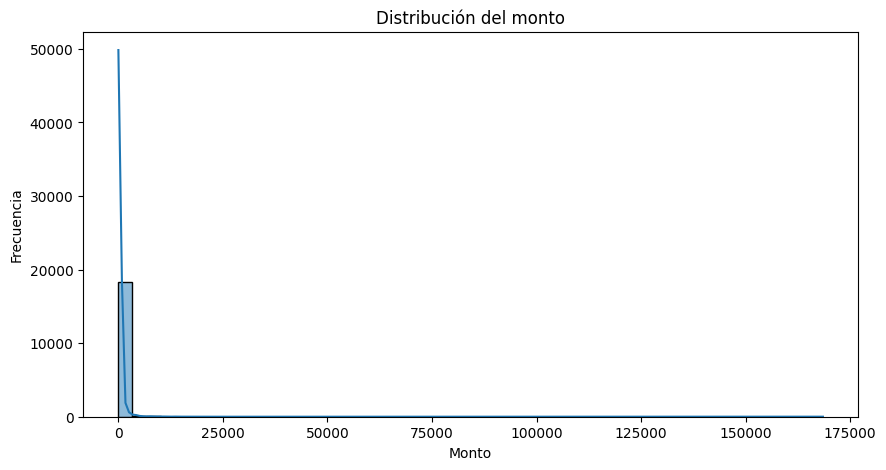

In [79]:
#Distribucion del monto
plt.figure(figsize=(10,5))
sns.histplot(df["Monto"], bins=50, kde=True)
plt.title("Distribución del monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.show()

In [80]:
#Identificar outliers con IQR
Q1 = df["Monto"].quantile(0.25)
Q3 = df["Monto"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Límite inferior: -312.63625
Límite superior: 941.59375


In [81]:
#ver
outliers = df[(df["Monto"] < limite_inferior) | (df["Monto"] > limite_superior)]

print("Outliers encontrados:", outliers.shape[0])
outliers.head()

Outliers encontrados: 1468


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día,Hora
27,576083,2021-11-14 08:22:00,17404,Sweden,1060,1238.48,2021,11,14,8
40,539049,2020-12-15 16:21:00,15615,United Kingdom,364,1048.64,2020,12,15,16
67,577783,2021-11-21 16:20:00,18139,United Kingdom,1644,2786.40,2021,11,21,16
95,569695,2021-10-05 15:35:00,16843,United Kingdom,938,993.88,2021,10,5,15
105,575854,2021-11-11 12:20:00,14125,United Kingdom,486,1111.08,2021,11,11,12


In [82]:
#eliminar externos outliers
outliers = df[(df["Monto"] < limite_inferior) | (df["Monto"] > limite_superior)]

print("Outliers encontrados:", outliers.shape[0])
outliers.head()

Outliers encontrados: 1468


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día,Hora
27,576083,2021-11-14 08:22:00,17404,Sweden,1060,1238.48,2021,11,14,8
40,539049,2020-12-15 16:21:00,15615,United Kingdom,364,1048.64,2020,12,15,16
67,577783,2021-11-21 16:20:00,18139,United Kingdom,1644,2786.40,2021,11,21,16
95,569695,2021-10-05 15:35:00,16843,United Kingdom,938,993.88,2021,10,5,15
105,575854,2021-11-11 12:20:00,14125,United Kingdom,486,1111.08,2021,11,11,12


In [83]:
#ventas por país
print("Registros disponibles para graficar:", df.shape)

Registros disponibles para graficar: (18562, 10)


In [84]:
ventas_pais = df.groupby("País")["Monto"].sum().sort_values(ascending=False)

ventas_pais.head(10)

País
United Kingdom    7308391.55
Netherlands        285446.34
Eire               265545.90
Germany            228867.14
France             209024.05
Australia          138521.31
Spain               61577.11
Switzerland         56443.95
Belgium             41196.34
Sweden              38378.33
Name: Monto, dtype: float64

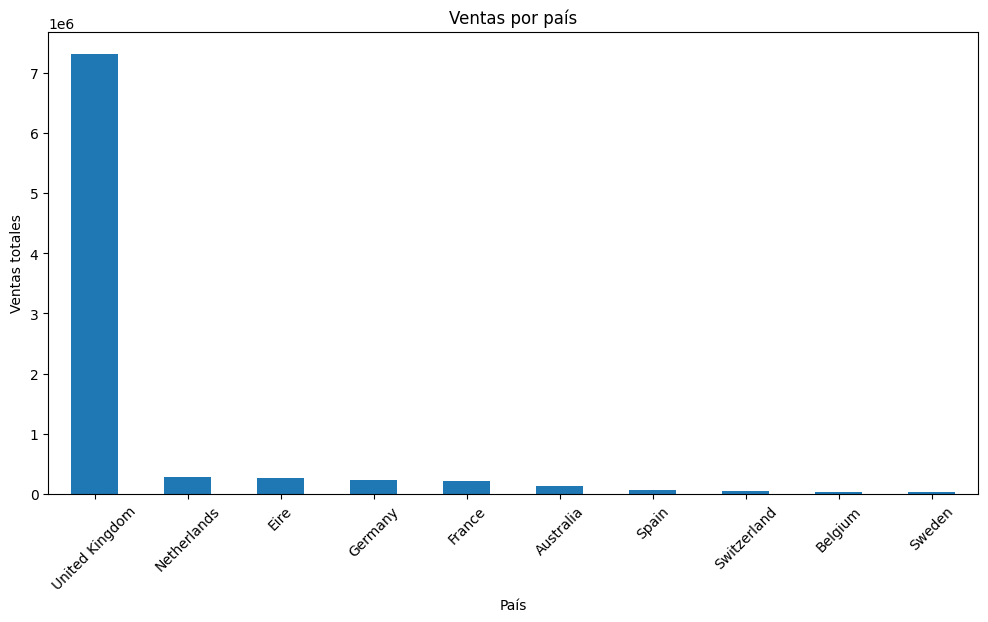

In [85]:
plt.figure(figsize=(12,6))
ventas_pais.head(10).plot(kind="bar")
plt.title("Ventas por país")
plt.xlabel("País")
plt.ylabel("Ventas totales")
plt.xticks(rotation=45)
plt.show()

In [86]:
#Verificacion final del dataset limpio
df.info()

<class 'pandas.DataFrame'>
Index: 18562 entries, 0 to 25951
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     18562 non-null  str           
 1   Fecha de factura  18562 non-null  datetime64[us]
 2   ID Cliente        18562 non-null  int64         
 3   País              18562 non-null  str           
 4   Cantidad          18562 non-null  int64         
 5   Monto             18562 non-null  float64       
 6   Año               18562 non-null  int32         
 7   Mes               18562 non-null  int32         
 8   Día               18562 non-null  int32         
 9   Hora              18562 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(4), int64(2), str(2)
memory usage: 1.3 MB


In [87]:
df.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
Año                 0
Mes                 0
Día                 0
Hora                0
dtype: int64

In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
df.describe()

,Fecha de factura,ID Cliente,Cantidad,Monto,Año,Mes,Día,Hora
count,18562,18562.000000,18562.000000,18562.000000,18562.000000,18562.000000,18562.000000,18562.000000
mean,2021-07-01 13:53:06.393707,15266.266782,278.448605,480.088778,2020.924523,7.424523,14.943918,12.503610
min,2020-12-01 08:26:00,12346.000000,1.000000,0.380000,2020.000000,1.000000,1.000000,6.000000
25%,2021-03-30 13:56:15,13777.000000,74.000000,157.700000,2021.000000,5.000000,7.000000,11.000000
50%,2021-07-12 14:21:30,15176.500000,155.000000,302.875000,2021.000000,8.000000,15.000000,12.000000
75%,2021-10-12 13:16:15,16779.000000,290.000000,471.257500,2021.000000,11.000000,22.000000,14.000000
max,2021-12-09 12:50:00,18287.000000,80995.000000,168469.600000,2021.000000,12.000000,31.000000,20.000000
std,NaN,1733.952850,971.837519,1676.772723,0.264166,3.437613,8.674015,2.372124


In [91]:
#Explorar dataset limpio
df.to_csv("ventas-por-factura.csv", index=False)

In [92]:
df.to_csv("Data_Limpio_Factura.csv", index=False)

In [93]:
print("Dataset limpio exportado correctamente.")
print("Tamaño final:", df.shape)

Dataset limpio exportado correctamente.
Tamaño final: (18562, 10)
